In [2]:
%load_ext autoreload
%autoreload 2

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sys import path
path.append('../../fourier/')
import frequency_estimate as fe

path.append('../../signals/')
import signals as sg


In [355]:
T = 500
fs = 2
nt = int(T*fs)
f0 = 0.015
freqs = np.arange(1,4)*f0
amps = [0.3, 1, 0.7]

t = np.arange(nt)/fs

# x = np.array([sg.cosine(T, fi, fs, amplitude=a)[1] for fi, a in zip(freqs, amps)]).mean(axis=0)
x = np.random.randn(x.size)

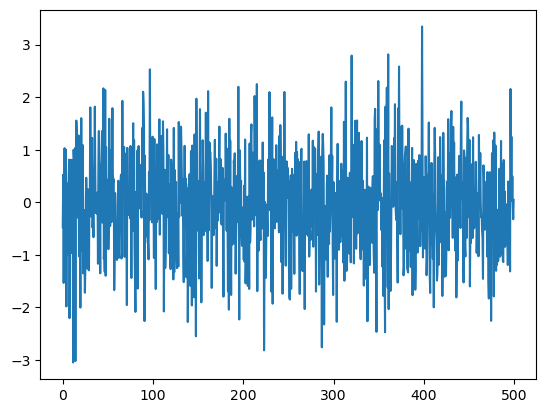

In [357]:
plt.plot(t, x)

In [358]:
freq, p = fe.periodogram(x, fs=fs)

In [359]:
res = fe.detect_periodogram_peaks(freq, p, [0.5, 0.8], [0.01, 0.05])

In [361]:
res['p_global<0.05'] = res.p_global<0.05

In [363]:
res.to_dataframe()

,frequency,power,Z,p_single,p_global,index,p_global<0.05
peak,,,,,,,
0,0.014,1.629268,1.611519,0.199584,0.990675,7,False
1,0.018,1.972040,1.950556,0.142195,0.960083,9,False
2,0.022,0.798953,0.790249,0.453732,0.999997,11,False
3,0.026,0.952445,0.942069,0.389820,0.999969,13,False
4,0.038,2.231924,2.207609,0.109963,0.913390,19,False
5,0.042,1.805954,1.786280,0.167582,0.978759,21,False
6,0.046,3.258600,3.223100,0.039831,0.574110,23,False


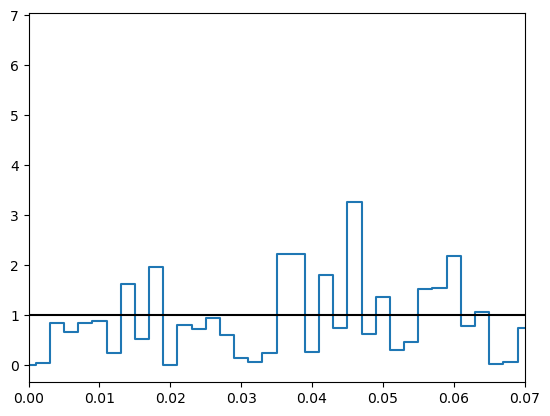

In [366]:
plt.step(freq, p, where='mid')
plt.xlim(0., 0.07)
plt.axhline(res.attrs['P0'], color='k')

for fi in res.frequency[res['p_global<0.05']]:
    plt.axvline(fi, color='r', alpha=0.2)

In [368]:
fe.detect_periodogram_peaks(freq, p, [0.5, 0.8], [0.01, 0.05], p_global_max=0.05)

<xarray.Dataset> Size: 0B
Dimensions:    (peak: 0)
Dimensions without coordinates: peak
Data variables:
    frequency  (peak) float64 0B 
    power      (peak) float64 0B 
    Z          (peak) float64 0B 
    p_single   (peak) float64 0B 
    p_global   (peak) float64 0B 
    index      (peak) int64 0B 
Attributes:
    P0:           1.0110141235468464
    noise_band:   [0.5, 0.8]
    signal_band:  [0.01, 0.05]
    N_tested:     21